In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import geopandas as gpd


In [3]:
df = pd.read_csv('Heracleum mantegazzianum.csv', low_memory=False)
df.sample(10)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Heracleum mantegazzianum
5660243,52.10,5.70,2018-11-26,0.0,0,0
7234958,52.35,6.05,2010-03-28,31.0,0,0
8879991,52.70,4.70,2018-02-03,1.0,0,0
9361381,52.75,6.95,2024-01-25,0.0,0,0
12404466,53.40,6.85,2019-07-31,109.0,0,0
6574899,52.25,5.60,2011-02-04,0.0,0,0
503547,51.20,5.85,2012-08-21,0.0,0,0
7509828,52.40,5.85,2010-10-16,0.0,0,0
3692106,51.80,4.45,2022-06-09,15.0,0,0
4609788,51.95,4.65,2022-11-30,9.0,2,0


In [4]:
df.info(verbose=True)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Heracleum mantegazzianum   str    
dtypes: float64(3), int64(1), str(2)
memory usage: 574.9 MB


,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,8.132578e+00,1.250141e+00
std,6.647267e-01,8.779710e-01,5.593690e+01,8.645628e+00
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,6.000000e+00,0.000000e+00
max,5.350000e+01,5.340000e+01,1.000400e+05,5.227000e+03


From the initial data description, it is visible that not all columns have the correct data types. The *eventDate* column should be formatted in **datetime** instead of in **string**, the *total_observations* column is formatted as **float**, and while that's usable, it should be of the **integer** type instead, and finally the *Heracleum mantegazzianum* column is in **string**, while that should be an **integer** column as well.

In [5]:
df[df.duplicated()]

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Heracleum mantegazzianum


From the initial data description, it is visible that not all columns have the correct data types. The *eventDate* column should be formatted in **datetime** instead of in **string**, the *total_observations* column is formatted as **float**, and while that's usable, it should be of the **integer** type instead, and finally the *Heracleum mantegazzianum* column is in **string**, while that should be an **integer** column as well.

From the above duplicate check, it is also visible that there are **no** duplicates. (Ruben)

In [6]:
for col in df.columns:
    print(f"\n{col}:\n", df[col].unique())
print(df.head(5))


decimalLatitude:
 [50.75 50.8  50.85 50.9  50.95 51.   51.05 51.1  51.15 51.2  51.25 51.3
 51.35 51.4  51.45 51.5  51.55 51.6  51.65 51.7  51.75 51.8  51.85 51.9
 51.95 52.   52.05 52.1  52.15 52.2  52.25 52.3  52.35 52.4  52.45 52.5
 52.55 52.6  52.65 52.7  52.75 52.8  52.85 52.9  52.95 53.   53.05 53.1
 53.15 53.2  53.25 53.3  53.35 53.4  53.45 53.5   3.55  3.65  3.75  3.5
  3.6   3.7   3.8   4.15  4.25  4.35  4.45  4.55  4.4   4.3   4.2   4.1 ]

decimalLongitude:
 [ 5.65  5.7   5.75  5.8   5.85  5.9   5.95  6.    5.6   6.05  6.1   6.15
  3.75  3.8   3.85  3.9   3.95  4.    4.05  5.55  3.35  3.4   3.45  3.5
  3.65  3.7   4.1   5.2   5.25  5.3   5.35  5.4   5.45  5.5   3.55  3.6
  4.15  4.2   5.1   5.15  4.25  4.3   4.35  4.4   5.05  6.2   4.5   4.55
  4.6   4.65  4.75  4.8   4.85  4.9   4.95  4.45  4.7   5.    6.35  6.25
  6.3   6.4   6.45  6.5   6.55  6.6   6.65  6.7   6.75  6.8   6.85  6.9
  6.95  7.    7.05  7.1   7.15  7.2  53.4  53.3  53.2  53.1  53.   52.9
 52.8  53.25 53.05 5

TLDR;
some **NAN** values in total_observations
Heracleum mantegazzianum array has some *unknown* and *-1 negative values* (Mika)

In [7]:
df['total_observations'] = pd.to_numeric(df['total_observations'], errors='coerce')
df['total_observations'] = df['total_observations'].fillna(0).astype(int)
#print(df['total_observations'].dtype, len(df['total_observations']))

I observed that the total_observations column was with float values and NaNs. To mitigate this, I converted all NaNs to 0 and all values from float to int. (Marcell)

In [8]:
df['Heracleum mantegazzianum'] = pd.to_numeric(df['Heracleum mantegazzianum'], errors='coerce')
df['Heracleum mantegazzianum'] = df['Heracleum mantegazzianum'].fillna(0).astype(int)
df['Heracleum mantegazzianum'] = df['Heracleum mantegazzianum'].clip(lower=0)
#print(df['Heracleum mantegazzianum'].isnull().sum(), df['Heracleum mantegazzianum'].dtype, len(df['Heracleum mantegazzianum']))

The Heracleum mantegazzianum column was originally in a string format. All unknown / NaN values were converted to 0 and all others including the new 0s were converted to integers. Furthermore, all values below 0 were raised to 0 as there was at least 1 instance where the row value was below 0 (-1). (Marcell)
I observed that the total_observations column had a; only round numbers and b; potential NaN values.
To mitigate this, I first converted every entry into either a number or an NaN value. Then, I filled every NaN with a 0 and converted all floats to integers. Because of domain knowledge and performance reasons, namely that an observation has to be a round number (There's no such thing as 0.5 observation), I converted all floats to integers.

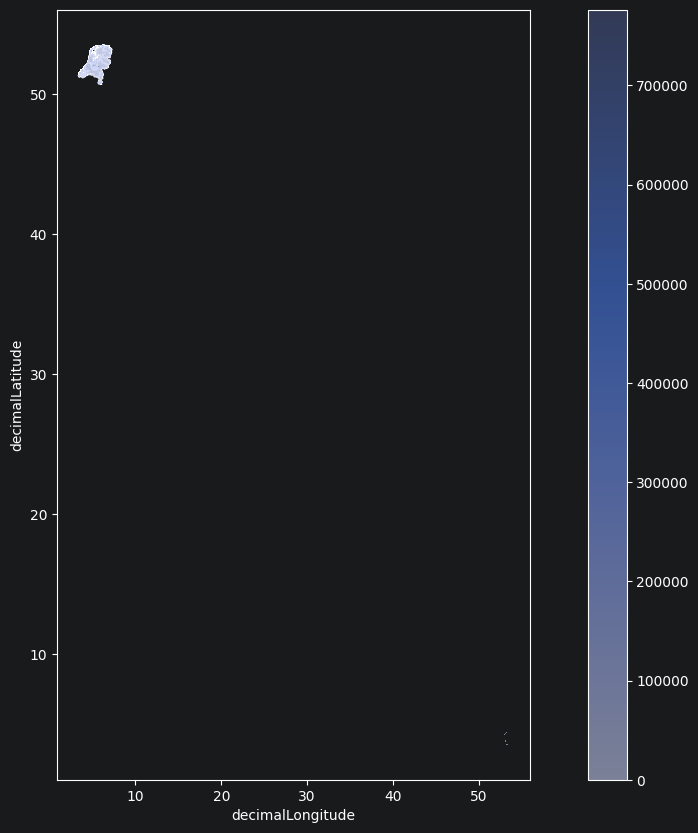

In [9]:
nl = gpd.read_file("gadm41_NLD.gpkg", layer="ADM_ADM_1")

fig, ax = plt.subplots(figsize=(15, 10))
nl.plot(ax=ax, color='lightgray', edgecolor='white')
sns.histplot(
    data=df,
    x=df['decimalLongitude'],
    y=df['decimalLatitude'],
    weights=df['total_observations'],
    cbar=True,
    binwidth=(0.05, 0.05),
    ax=ax,
    alpha=0.6,
)

plt.show()

I took the as-is latitude and longitude coöridnates, and applied them in a distplot to show distribution of observations by using "total observations" as a weight. This is done to learn where most observations are made. This means we have also learnt that some observations appear to have been made in Somalia! Either that or. They have simply been inverted. This is something to fix before we move forward.

We can either choose to inverse these values and fix them, or choose to remove them. Ideally, we shall do the former.